# Baseline: Classification via Promting

## Create a dataset

In [11]:
from utils.data_load import data_load

train, test = data_load()

Using the latest cached version of the module from C:\Users\Mariz\.cache\huggingface\modules\datasets_modules\datasets\theatticusproject--cuad-qa\01ed7dc61ab84230462731422e77cbb6f54ea8590b22a2d881b594f4d7f3746c (last modified on Fri Jun 19 11:07:39 2026) since it couldn't be found locally at theatticusproject/cuad-qa, or remotely on the Hugging Face Hub.


Train: 800, Test: 160


## Explorative Dataanalysis
- looking for the class distribution -> no class imbalance

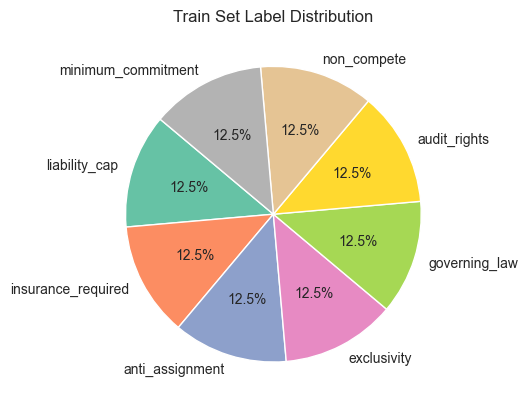

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

train_df = pd.DataFrame(train)
plt.pie(train_df["label"].value_counts(), labels=train_df["label"].value_counts().index, autopct="%1.1f%%", startangle=140)
plt.title("Train Set Label Distribution")
plt.show()

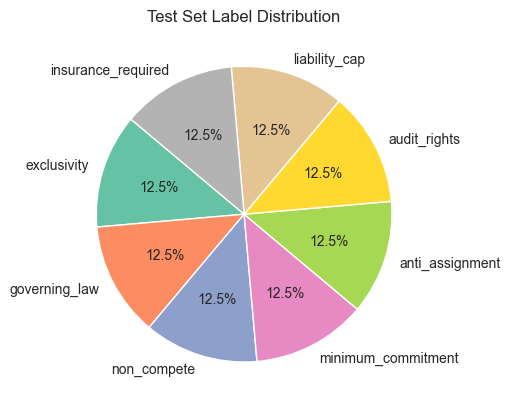

In [13]:
test_df = pd.DataFrame(test)
plt.pie(test_df["label"].value_counts(), labels=test_df["label"].value_counts().index, autopct="%1.1f%%", startangle=140)
plt.title("Test Set Label Distribution")
plt.show()

## Baseline: Classification via Promting
- selected model qwen3.5-0.8b

### Zero-shot vs few-shot promting

In [18]:
CATEGORIES = list(train_df["label"].unique())

In [19]:
MODEL = "qwen3.5:0.8b"
ZERO_SHOT_PROMT = f""" Classify the following legal clause into one of the following categories: {CATEGORIES}. Output the SINGLE label that best matches the clause below. 
                       CLAUSE: """

In [26]:
few_shot_examples = []
for label in CATEGORIES:
    class_examples = [item for item in train if item["label"] == label][:5] 
    for example in class_examples:
        few_shot_examples.append(f"EXAMPLE: {example['text']} LABEL: {example['label']}")

FEW_SHOT_PROMT = f""" Classify the following legal clause into one of the following categories:  {CATEGORIES}.
                      Here are some examples of clauses and their corresponding labels to help you understand the categories:{few_shot_examples}. 
                      Output the SINGLE label that best matches the clause below.
                      CLAUSE: """

In [23]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-0.8B")

len(tokenizer.encode(FEW_SHOT_PROMT)) #check token length of one example to estimate how many examples we can fit in the context window of the model

3221

### Generating predictions

In [32]:
import tqdm as tqdm
from ollama import chat

def classify_clause(model, clause, promt):
    response = chat(model=MODEL,
                    messages=[{"role": "system", "content": "You are a legal assistant that classifies legal clauses into specific categories. Always output ONLY ONE category label without any explanation."},
                              {"role": "user", "content": f"{promt} {clause}"}])
    return response.message.content.strip()

def predict(model, clauses, promt):
    prediction_df = []
    for clause in tqdm.tqdm(clauses):
        pred = classify_clause(model, clause, promt)
        prediction_df.append({"text": clause, "label": pred})
    return prediction_df